In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')

from train_functions import train_epochs
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

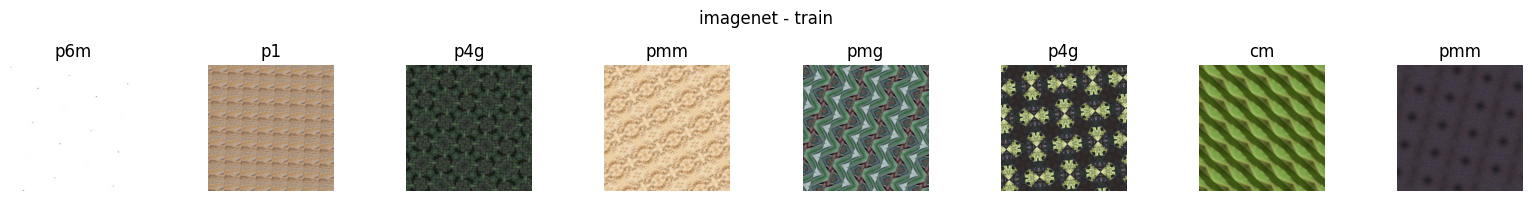

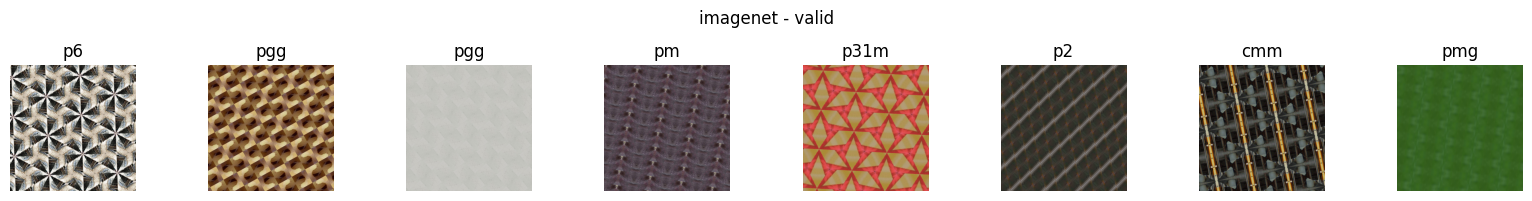

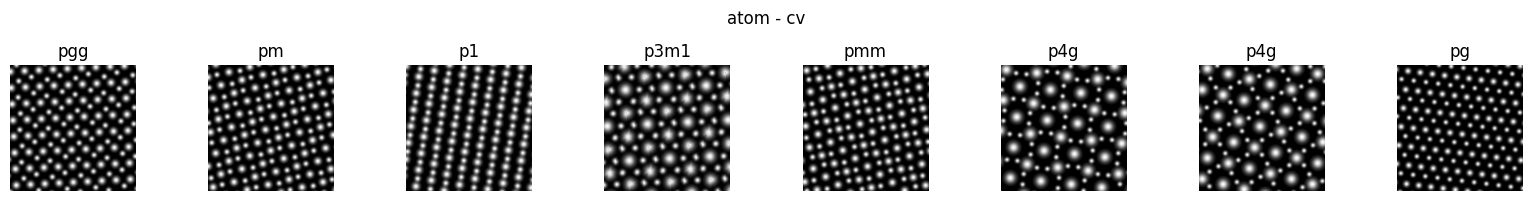

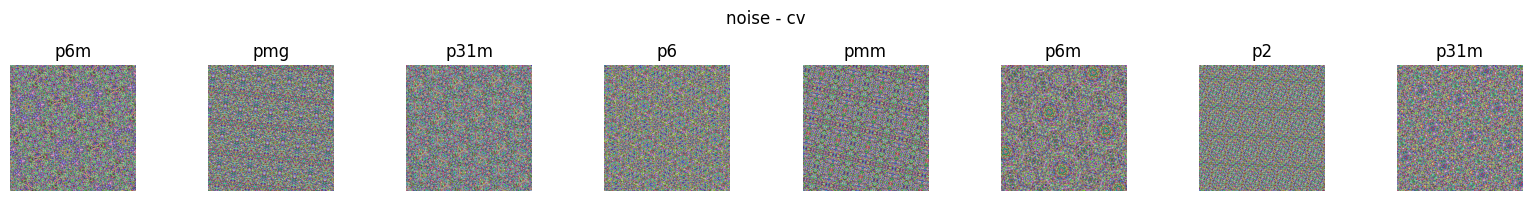

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8)
train_dl = DataLoader(train_ds, batch_size=300, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=300, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# # atom
atom_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=300, shuffle=False, num_workers=4)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

# # noise
noise_ds = hdf5_dataset('/mnt/d/datasets/symmetry_dataset/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='noise', transform=transforms.ToTensor())
noise_dl = DataLoader(noise_ds, batch_size=300, shuffle=False, num_workers=4)
viz_dataloader(noise_dl, label_converter=label_converter, title='noise - cv')

In [3]:
import sys
sys.path.append('../../src/benchmark/')
from build_model import resnet50_

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import torch.nn.functional as F

class ScaleAdaptiveModel(nn.Module):
    def __init__(self, pretrained_model):
        super(ScaleAdaptiveModel, self).__init__()
        self.backbone = pretrained_model
        self.fc_classifier = self.backbone.fc
        self.backbone.fc = nn.Identity()  # Assuming you want features not classification
        
        # Initialize the scaling factors to be close to what might be expected if images are larger
        self.scale_factors = nn.Parameter(torch.tensor([0.8, 0.8]))  # Starting guesses for downscaling

    def stn(self, x):
        theta = torch.diag(self.scale_factors).view(1, 2, 2)
        theta = theta.repeat(x.size(0), 1, 1)  # Repeat for each image in the batch

        # Extend theta for affine_grid which expects Nx2x3
        affine_mat = torch.zeros(theta.size(0), 2, 3).to(theta.device)
        affine_mat[:, :, :2] = theta
        affine_mat[:, :, 2] = 0  # No translation

        grid = F.affine_grid(affine_mat, x.size(), align_corners=False)
        x = F.grid_sample(x, grid, align_corners=False)
        return x

    def forward(self, x):
        # Apply scaling transformation
        x = self.stn(x)
        # Pass the transformed input through the backbone
        x = self.backbone(x)
        x = self.fc_classifier(x)
        return x

# Load your pretrained ResNet50 model
pretrained_resnet50 = models.resnet50(pretrained=True)
# Freeze all the parameters in the backbone
for param in pretrained_resnet50.parameters():
    param.requires_grad = False

# Instantiate your model
model = ScaleAdaptiveModel(pretrained_resnet50)

input_tensor = torch.randn((2, 3, 256, 256))  # Example input
output = model(input_tensor)
print(output.shape)  # Output shape from the backbone

# model = torch.nn.DataParallel(model, device_ids=[0,1])
# model

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([2, 1000])


In [5]:
config = {
    'dataset': '10 million datasets',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '06042024-benchmark-resnet50_from_scratch-v5_10m'

# train

In [6]:
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [7]:
device = torch.device('cuda:0')
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_dl_list=[atom_dl, noise_dl], cv_name_list=['atom', 'noise'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir='../../../saved_models/', tracking=True)

Epoch: 1/20


  0%|          | 0/28561 [00:00<?, ?it/s]

  6%|▌         | 1748/28561 [2:31:50<38:49:08,  5.21s/it]


KeyboardInterrupt: 